In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pickle
import os
import matplotlib.ticker as mticker

def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu_t = X_t.mean().values
    mu_tk = X_tk.mean().values

    Xc_t = X_t.values - mu_t
    Xc_tk = X_tk.values - mu_tk

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    std_t = X_t.std(ddof=0).values
    std_tk = X_tk.std(ddof=0).values

    # Avoid division by zero
    std_t[std_t == 0] = 1e-8
    std_tk[std_tk == 0] = 1e-8

    return Sigma_k / np.outer(std_tk, std_t)

k_values = [5]

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

def out_of_sample_daily_analysis(n_months: int, k_val: int = 5):
    years = range(2014, 2025)
    metrics = ["hrm", "pozzi"]
    decile_pairs = [(i, 11 - i) for i in range(1, 6)]
    
    # Dicionários de armazenamento
    results = {m: {f"d{p}_d{c}": [] for p, c in decile_pairs} for m in metrics}
    results_mcap = []

    # Carrega metadados do market cap
    df_mcap_meta = pd.read_csv("../../data/02_clean/metadata - metadata_att (1).csv")

    # 1. Loop de Processamento OOS
    for year in years:
        # Define o horizonte de teste (Ex: Jan a Mar do ano seguinte se n_months=3)
        end_date = (
            pd.Timestamp(year=year + 1, month=n_months, day=1)
            + pd.offsets.MonthEnd(0)
        )
        
        try:
            path_ret = f"../../data/02_clean/returns_new_{year + 1}.parquet"
            # Carrega apenas o período OOS definido
            full_ret = pd.read_parquet(path_ret).loc[:end_date]
            log_ret_full = np.log1p(full_ret)
        except Exception as e:
            print(f"Erro ao carregar retornos para {year+1}: {e}")
            continue

        # Market Cap OOS Calculation
        try:
            mcap_col = f"mcap_{year}"
            df_mcap_year = df_mcap_meta[(df_mcap_meta["Ticker"].isin(full_ret.columns))].copy()
            df_mcap_year[mcap_col] = (
                df_mcap_year[mcap_col]
                .replace("#ERROR!", np.nan)
                .astype(str)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df_mcap_year[mcap_col] = pd.to_numeric(df_mcap_year[mcap_col], errors="coerce")
            df_mcap_year = df_mcap_year.dropna(subset=[mcap_col])

            p90 = df_mcap_year[mcap_col].quantile(0.9)
            p10 = df_mcap_year[mcap_col].quantile(0.1)

            large_tickers = df_mcap_year[df_mcap_year[mcap_col] >= p90]["Ticker"].tolist()
            small_tickers = df_mcap_year[df_mcap_year[mcap_col] <= p10]["Ticker"].tolist()

            r_large = log_ret_full[list(set(large_tickers).intersection(full_ret.columns))].mean(axis=1)
            r_small = log_ret_full[list(set(small_tickers).intersection(full_ret.columns))].mean(axis=1)

            X_mcap = pd.concat([r_large, r_small], axis=1).dropna()
            X_mcap.columns = ["Large", "Small"]
            
            if len(X_mcap) >= 10:
                total_ll_mcap = 0
                max_lag = 5
                for l in range(1, max_lag + 1):
                    acm_mcap = autocorrelation_matrix(X_mcap, lag=l)
                    lag_matrix_mcap = acm_mcap - acm_mcap.T
                    # Influência do Big sobre o Small: lag_matrix_mcap[0, 1]
                    total_ll_mcap += lag_matrix_mcap[0, 1]
                
                results_mcap.append(pd.DataFrame([total_ll_mcap], index=[year + 1], columns=["daily_ll"]))
        except Exception as e:
            print(f"Erro mcap ano {year+1}: {e}")

        for metric in metrics:
            for p_idx, c_idx in decile_pairs:
                p_label = f"decil_{p_idx}_{year}_{metric}"
                c_label = f"decil_{c_idx}_{year}_{metric}"
                
                try:
                    cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                    cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                    
                    r_p = log_ret_full[cols_p.intersection(full_ret.columns)].mean(axis=1)
                    r_c = log_ret_full[cols_c.intersection(full_ret.columns)].mean(axis=1)
                    
                    X = pd.concat([r_p, r_c], axis=1).dropna()
                    X.columns = ["Low", "High"]
                    
                    if len(X) < 10: continue
                    
                    total_ll = 0
                    max_lag = 5
                    for l in range(1, max_lag + 1):
                        acm = autocorrelation_matrix(X, lag=l)
                        lag_matrix = acm - acm.T
                        
                        if metric == "hrm":
                            total_ll += lag_matrix[0, 1]
                        else:
                            total_ll += lag_matrix[0, 1]
                            
                    results[metric][f"d{p_idx}_d{c_idx}"].append(
                        pd.DataFrame([total_ll], index=[year + 1], columns=["daily_ll"])
                    )
                except Exception as e:
                    continue

    # --- PLOTTING ---
    sns.set_theme(style="white", context="paper")
    
    TITLE_SIZE = 26
    LABEL_SIZE = 22
    TICK_SIZE = 18
    ANNOTATE_SIZE = 16
    LINE_WIDTH_MAIN = 4.0
    LINE_WIDTH_BACK = 1.5
    MARKER_SIZE = 10

    # Consolida os dados
    final_dfs = {m: {p: pd.concat(v) for p, v in pairs.items() if v} 
                 for m, pairs in results.items()}
    
    if results_mcap:
        df_mcap = pd.concat(results_mcap)
    else:
        df_mcap = pd.DataFrame()

    fig, axes = plt.subplots(1, 2, figsize=(24, 10), sharey=True)
    
    # Paper Palette
    metric_colors = {"hrm": "#2E5C6E", "pozzi": "#2E5C6E"}
    mcap_color = "#A93226" # Vermelho destaque para Market Cap
    
    for col, metric in enumerate(metrics):
        ax = axes[col]
        m_data = final_dfs[metric]
        main_color = metric_colors[metric]
        
        # 1. Pares intermediários (cinza)
        for p_key in ["d2_d9", "d3_d8", "d4_d7", "d5_d6"]:
            if p_key in m_data:
                df = m_data[p_key]
                ax.plot(df.index, df["daily_ll"], color="#BDC3C7", lw=LINE_WIDTH_BACK, alpha=0.45, zorder=1)
                ax.annotate(p_key.replace("_", "-"), xy=(df.index[-1], df["daily_ll"].iloc[-1]), 
                            xytext=(5, 0), textcoords='offset points', fontsize=ANNOTATE_SIZE-2, 
                            color="#7F8C8D", va='center')

        # 2. Market Cap Baseline
        if not df_mcap.empty:
            ax.plot(df_mcap.index, df_mcap["daily_ll"], color=mcap_color, 
                    lw=LINE_WIDTH_MAIN-1, ls="--", marker="s", markersize=MARKER_SIZE-2, zorder=4,
                    label="Big -> Small")
            # ax.annotate("Market Cap (L-S)", xy=(df_mcap.index[-1], df_mcap["daily_ll"].iloc[-1]), 
            #             xytext=(8, -12), textcoords='offset points', fontsize=ANNOTATE_SIZE, 
            #             fontweight='bold', color=mcap_color, va='center')

        # 3. Destaque d1_d10
        if "d1_d10" in m_data:
            df = m_data["d1_d10"]
            ax.plot(df.index, df["daily_ll"], color=main_color, lw=LINE_WIDTH_MAIN, marker="o", markersize=MARKER_SIZE, zorder=5,
            label="Central -> Peripheral")
            # ax.annotate("d1-d10 (Extremes)", xy=(df.index[-1], df["daily_ll"].iloc[-1]), 
            #             xytext=(8, 12), textcoords='offset points', fontsize=ANNOTATE_SIZE, 
            #             fontweight='bold', color=main_color, va='center')

        if metric == "hrm":
            metric = "hcm"
        ax.set_title(f"{metric.upper()}", fontsize=TITLE_SIZE, fontweight="bold", pad=25)
        ax.axhline(0, color="black", lw=2, ls="--", alpha=0.6)
        ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
        if col == 0: ax.set_ylabel("Lead-Lag Measure", fontsize=LABEL_SIZE, fontweight="bold")
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        
        # Ajuste do limite X para caber as anotações
        if not df_mcap.empty and "d1_d10" in m_data:
            ax.set_xlim(years[0]+0.5, years[-1]+1.5)
        else:
            ax.set_xlim(years[0]+1, years[-1]+1.5)

    sns.despine(fig=fig)
    plt.tight_layout(rect=[0, 0, 0.94, 1])
    plt.legend(fontsize=20)
    
    os.makedirs("../../figures", exist_ok=True)
    plt.savefig(f"../../figures/oos_daily_comparison_{n_months}.png", dpi=300, bbox_inches="tight")
    plt.show()

# Exemplo de uso:
# out_of_sample_daily_analysis(n_months=3)


/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


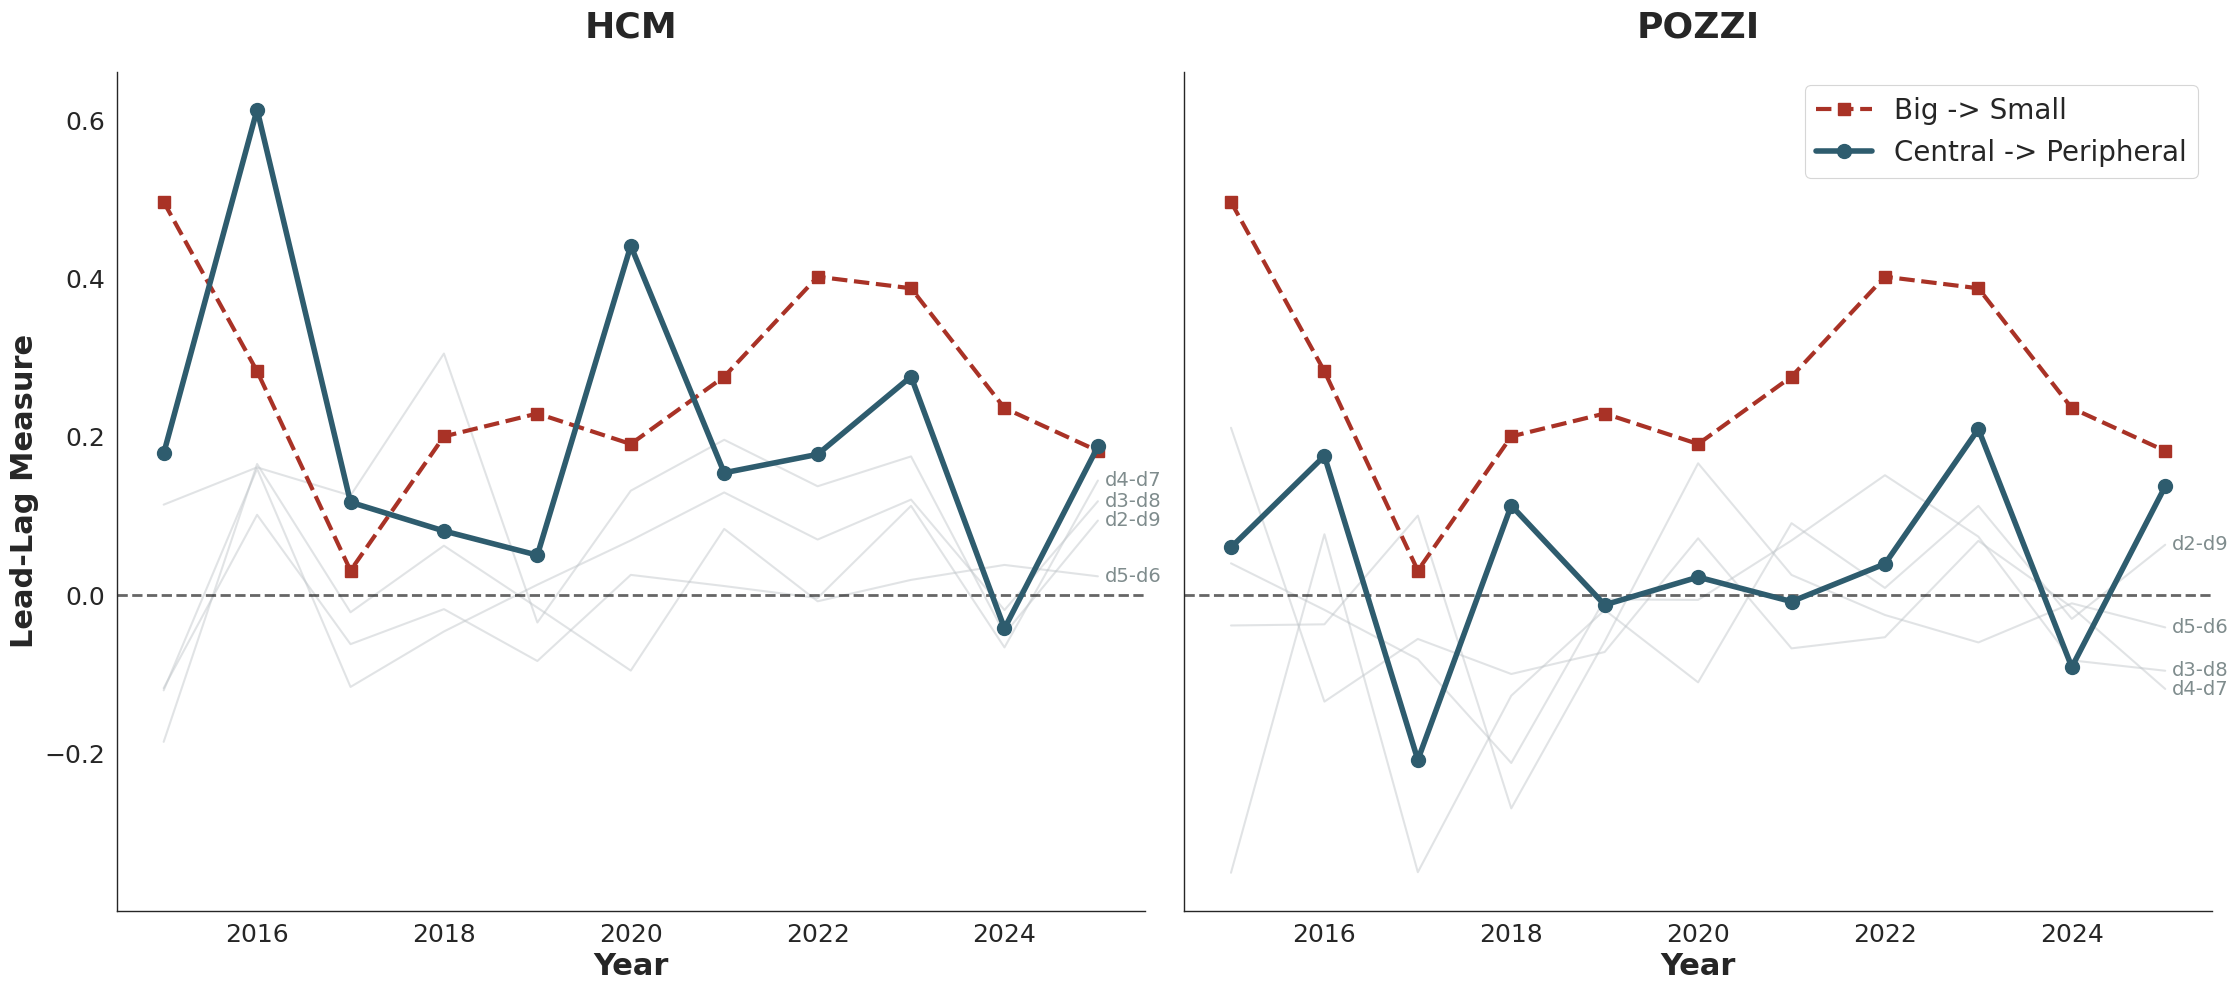

In [22]:
out_of_sample_daily_analysis(n_months=12)